# Cancer Lifestyle Medicine - Data Analysis

Dataset: `adult24.csv`

In [1]:
import pandas as pd

df = pd.read_csv('adult24.csv')

## Question CAN.0010.00.1 (ID: 109)

**Variable:** `CANEV_A`  
**Question:** Have you EVER been told by a doctor or other health professional that you had Cancer or a malignancy of any kind?

**Response codes:**
- `1` = Yes
- `2` = No
- `7` = Refused
- `9` = Don't know

In [2]:
# Count of each response for CANEV_A
canev_counts = df['CANEV_A'].value_counts().sort_index()

response_labels = {1: 'Yes (cancer)', 2: 'No', 7: 'Refused', 9: "Don't know"}
canev_counts.index = canev_counts.index.map(response_labels)

print("CANEV_A - Ever told had cancer?")
print(canev_counts.to_string())
print(f"\nTotal respondents: {len(df)}")

CANEV_A - Ever told had cancer?
CANEV_A
Yes (cancer)     4434
No              28165
Refused            21
Don't know          9

Total respondents: 32629


In [3]:
# Number of people who have had cancer (CANEV_A == 1)
num_cancer = (df['CANEV_A'] == 1).sum()
total = df['CANEV_A'].notna().sum()
pct = num_cancer / total * 100

print(f"Number of people who have had cancer (CANEV_A = 1): {num_cancer}")
print(f"Total respondents with a valid answer:               {total}")
print(f"Percentage with cancer:                              {pct:.2f}%")

Number of people who have had cancer (CANEV_A = 1): 4434
Total respondents with a valid answer:               32629
Percentage with cancer:                              13.59%


In [4]:
print(df.shape)

(32629, 630)


In [5]:
vars_needed = [
    "SEX_A",
    "HISPALLP_A",
    "RACEALLP_A",
    "EDUCP_A",
    "CANEV_A",
    "WTFA_A"      # add weight column now
]

analysis_df = df[vars_needed].copy()

analysis_df.head()

,SEX_A,HISPALLP_A,RACEALLP_A,EDUCP_A,CANEV_A,WTFA_A
0,1,2,1,5,2,5780.565
1,1,2,1,5,2,3994.244
2,1,2,1,5,2,6636.755
3,1,2,1,4,2,13767.420
4,2,3,2,9,2,18880.030


In [6]:
analysis_df.isna().sum()

SEX_A         0
HISPALLP_A    0
RACEALLP_A    0
EDUCP_A       0
CANEV_A       0
WTFA_A        0
dtype: int64

In [7]:
analysis_df["SEX_A"].value_counts()

SEX_A
2    17639
1    14985
7        3
9        2
Name: count, dtype: int64

In [8]:
analysis_df["HISPALLP_A"].value_counts()

HISPALLP_A
2    21770
1     4762
3     3296
4     1869
7      411
5      268
6      253
Name: count, dtype: int64

In [9]:
analysis_df["RACEALLP_A"].value_counts()

RACEALLP_A
1    24452
2     3447
3     1894
8     1661
6      476
4      347
5      313
9       32
7        7
Name: count, dtype: int64

In [10]:
analysis_df["EDUCP_A"].value_counts()

EDUCP_A
4     7605
8     7482
5     4698
9     3627
7     3017
1     2131
6     1335
10    1250
3      803
2      534
99     112
97      35
Name: count, dtype: int64

In [11]:
cancer_map = {
    1: "Yes",
    2: "No",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't Know"
}

sex_map = {
    1: "Male",
    2: "Female",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

race_map = {
    1: "White",
    2: "Black/African American",
    3: "American Indian/Alaska Native",
    4: "Asian",
    5: "Native Hawaiian/Pacific Islander",
    6: "Multiple Races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

educ_map = {
    0: "Never attended",
    1: "Grade 1–11",
    2: "12th grade, no diploma",
    3: "GED",
    4: "High School Graduate",
    5: "Some College",
    6: "Associate (occupational)",
    7: "Associate (academic)",
    8: "Bachelor's",
    9: "Master's",
    10: "Professional/Doctorate",
    97: "Refused",
    98: "Not Ascertained",
    99: "Don't know"
}

In [12]:
analysis_df["SEX_label"] = analysis_df["SEX_A"].map(sex_map)
analysis_df["RACE_label"] = analysis_df["RACEALLP_A"].map(race_map)
analysis_df["EDUC_label"] = analysis_df["EDUCP_A"].map(educ_map)
analysis_df["CANEV_label"] = analysis_df["CANEV_A"].map(cancer_map)

In [13]:
analysis_df[["SEX_A","SEX_label","RACEALLP_A","RACE_label","EDUCP_A","EDUC_label"]].head()

,SEX_A,SEX_label,RACEALLP_A,RACE_label,EDUCP_A,EDUC_label
0,1,Male,1,White,5,Some College
1,1,Male,1,White,5,Some College
2,1,Male,1,White,5,Some College
3,1,Male,1,White,4,High School Graduate
4,2,Female,2,Black/African American,9,Master's


In [14]:
analysis_df["CANEV_label"].value_counts()

CANEV_label
No            28165
Yes            4434
Refused          21
Don't Know        9
Name: count, dtype: int64

In [15]:
clean_df = analysis_df[
    (analysis_df["CANEV_A"].isin([1,2])) &
    (analysis_df["SEX_A"].isin([1,2]))
].copy()

clean_df["SEX_label"] = clean_df["SEX_A"].map(sex_map)
clean_df["RACE_label"] = clean_df["RACEALLP_A"].map(race_map)
clean_df["EDUC_label"] = clean_df["EDUCP_A"].map(educ_map)
clean_df["CANEV_label"] = clean_df["CANEV_A"].map(cancer_map)

In [16]:
clean_df.columns

Index(['SEX_A', 'HISPALLP_A', 'RACEALLP_A', 'EDUCP_A', 'CANEV_A', 'WTFA_A',
       'SEX_label', 'RACE_label', 'EDUC_label', 'CANEV_label'],
      dtype='object')

In [17]:
clean_df["Cancer"] = (clean_df["CANEV_A"] == 1).astype(int)

In [18]:
clean_df.head()

,SEX_A,HISPALLP_A,RACEALLP_A,EDUCP_A,CANEV_A,WTFA_A,SEX_label,RACE_label,EDUC_label,CANEV_label,Cancer
0,1,2,1,5,2,5780.565,Male,White,Some College,No,0
1,1,2,1,5,2,3994.244,Male,White,Some College,No,0
2,1,2,1,5,2,6636.755,Male,White,Some College,No,0
3,1,2,1,4,2,13767.420,Male,White,High School Graduate,No,0
4,2,3,2,9,2,18880.030,Female,Black/African American,Master's,No,0


In [19]:
clean_df["CANEV_label"].value_counts(normalize=True)*100

CANEV_label
No     86.396269
Yes    13.603731
Name: proportion, dtype: float64

In [20]:
pd.crosstab(clean_df["SEX_label"], clean_df["CANEV_label"], normalize="index")

CANEV_label,No,Yes
SEX_label,,
Female,0.858513,0.141487
Male,0.870382,0.129618


In [21]:
pd.crosstab(clean_df["RACE_label"], clean_df["CANEV_label"], normalize="index")

CANEV_label,No,Yes
RACE_label,,
American Indian/Alaska Native,0.950343,0.049657
Asian,0.893372,0.106628
Black/African American,0.916110,0.083890
Don't know,0.937500,0.062500
Multiple Races,0.964211,0.035789
Native Hawaiian/Pacific Islander,0.843450,0.156550
Not Ascertained,0.962048,0.037952
Refused,1.000000,0.000000
White,0.841004,0.158996


In [22]:
pd.crosstab(clean_df["EDUC_label"], clean_df["CANEV_label"], normalize="index")

CANEV_label,No,Yes
EDUC_label,,
"12th grade, no diploma",0.889513,0.110487
Associate (academic),0.863546,0.136454
Associate (occupational),0.851574,0.148426
Bachelor's,0.861100,0.138900
Don't know,0.928571,0.071429
GED,0.863014,0.136986
Grade 1–11,0.884922,0.115078
High School Graduate,0.869571,0.130429
Master's,0.853753,0.146247


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

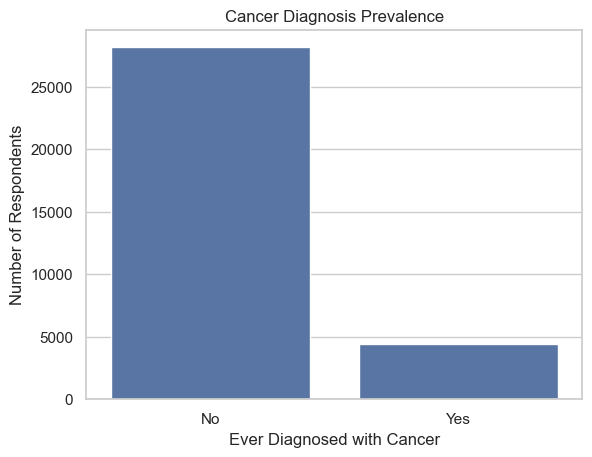

In [24]:
sns.countplot(data=clean_df, x="CANEV_label")

plt.title("Cancer Diagnosis Prevalence")
plt.xlabel("Ever Diagnosed with Cancer")
plt.ylabel("Number of Respondents")

plt.show()

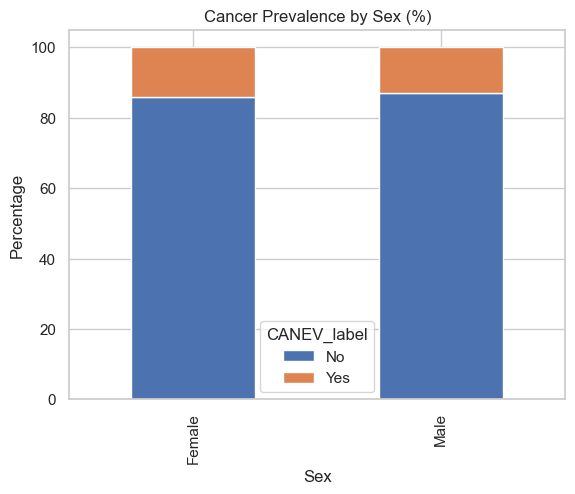

In [25]:
sex_table = pd.crosstab(clean_df["SEX_label"], clean_df["CANEV_label"], normalize="index")

(sex_table*100).plot(kind="bar", stacked=True)

plt.title("Cancer Prevalence by Sex (%)")
plt.xlabel("Sex")
plt.ylabel("Percentage")

plt.show()

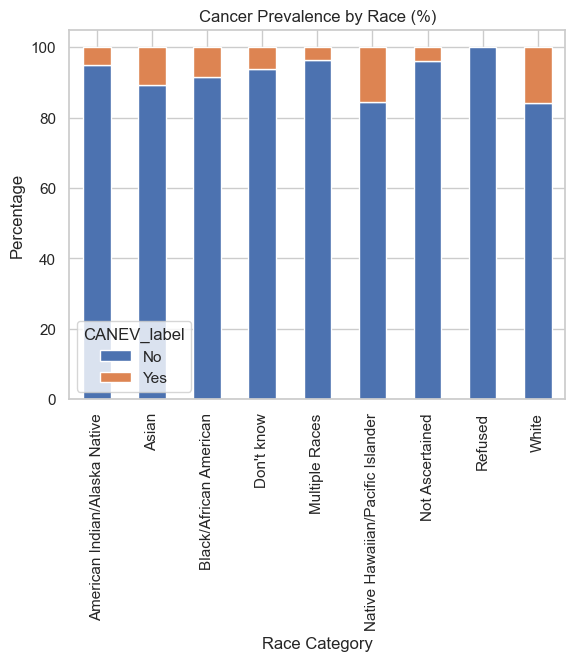

In [26]:
race_table = pd.crosstab(clean_df["RACE_label"], clean_df["CANEV_label"], normalize="index")

(race_table*100).plot(kind="bar", stacked=True)

plt.title("Cancer Prevalence by Race (%)")
plt.xlabel("Race Category")
plt.ylabel("Percentage")

plt.show()

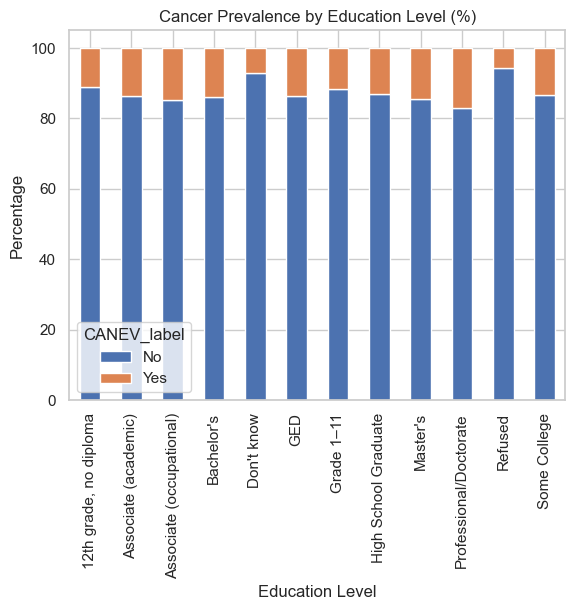

In [27]:
edu_table = pd.crosstab(clean_df["EDUC_label"], clean_df["CANEV_label"], normalize="index")

(edu_table*100).plot(kind="bar", stacked=True)

plt.title("Cancer Prevalence by Education Level (%)")
plt.xlabel("Education Level")
plt.ylabel("Percentage")

plt.show()

In [28]:
heatmap_data = (
    clean_df
    .groupby(["RACE_label","EDUC_label"])["Cancer"]
    .mean()
    .unstack()
)

# rows = race
# columns = education
# values = cancer prevalence (proportion with cancer)

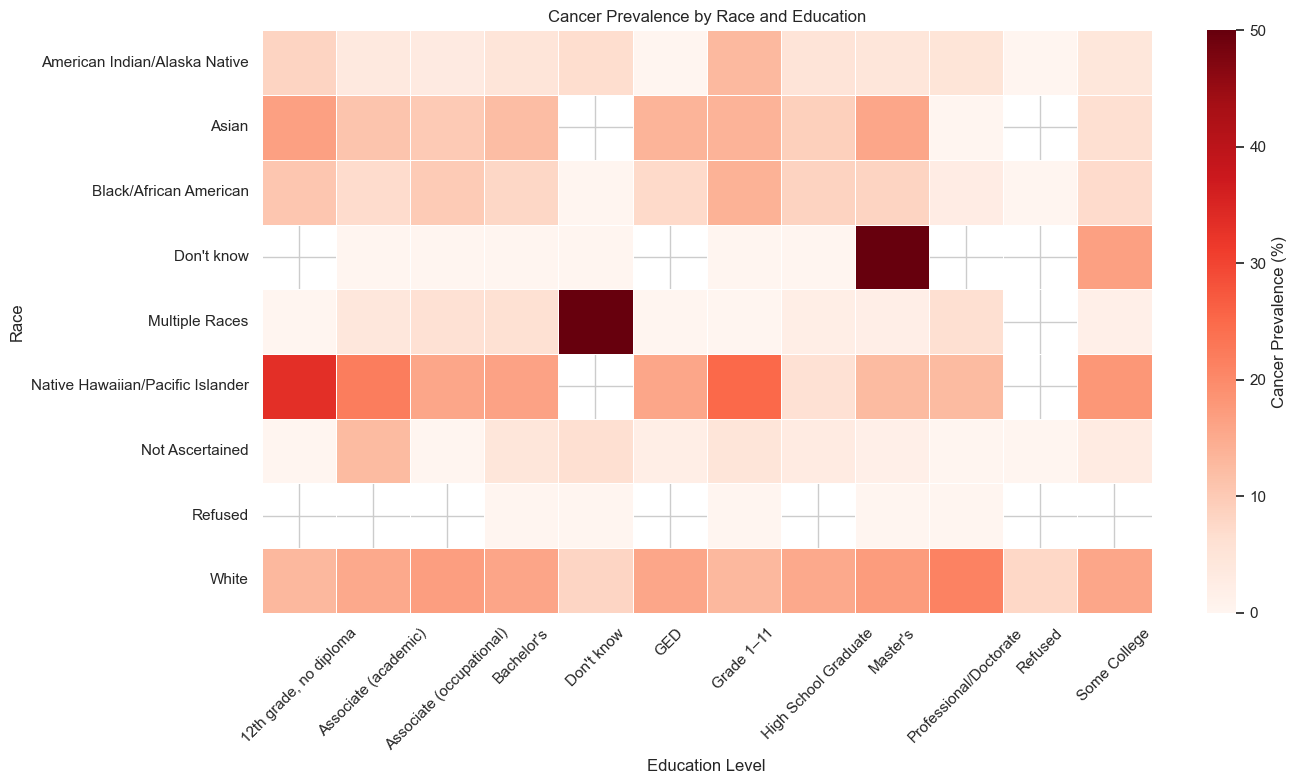

In [29]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data * 100,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label":"Cancer Prevalence (%)"}
)

plt.title("Cancer Prevalence by Race and Education")
plt.xlabel("Education Level")
plt.ylabel("Race")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

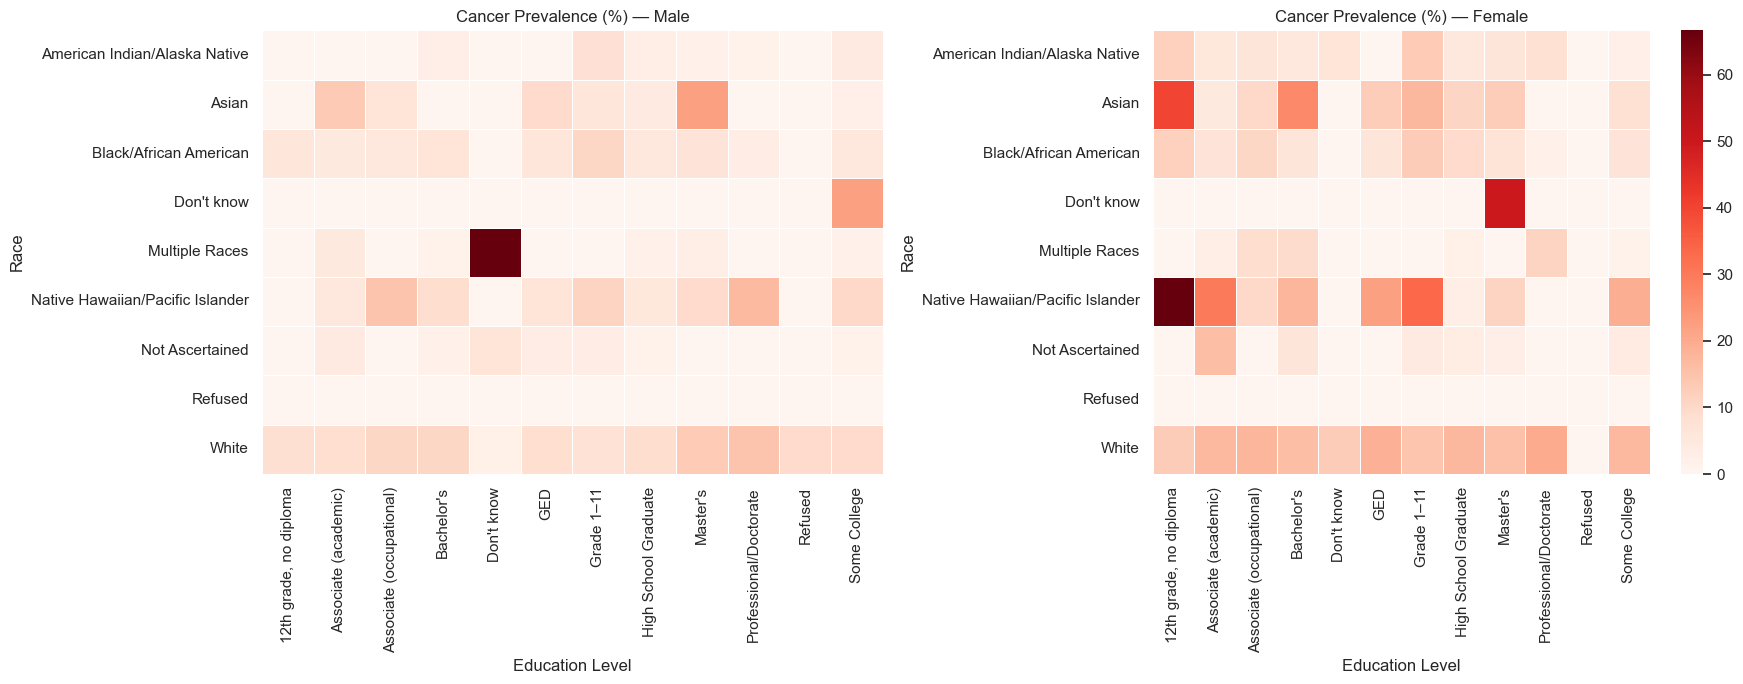

In [30]:
fig, axes = plt.subplots(1,2, figsize=(18,7))

for i, sex in enumerate(["Male","Female"]):

    subset = clean_df[clean_df["SEX_label"] == sex]

    data = (
        subset
        .groupby(["RACE_label","EDUC_label"])["Cancer"]
        .mean()
        .unstack()
        .fillna(0)
    )

    sns.heatmap(
        data * 100,
        fmt=".1f",
        cmap="Reds",
        linewidths=0.5,
        ax=axes[i],
        cbar=i==1
    )

    axes[i].set_title(f"Cancer Prevalence (%) — {sex}")
    axes[i].set_xlabel("Education Level")
    axes[i].set_ylabel("Race")

plt.tight_layout()
plt.show()

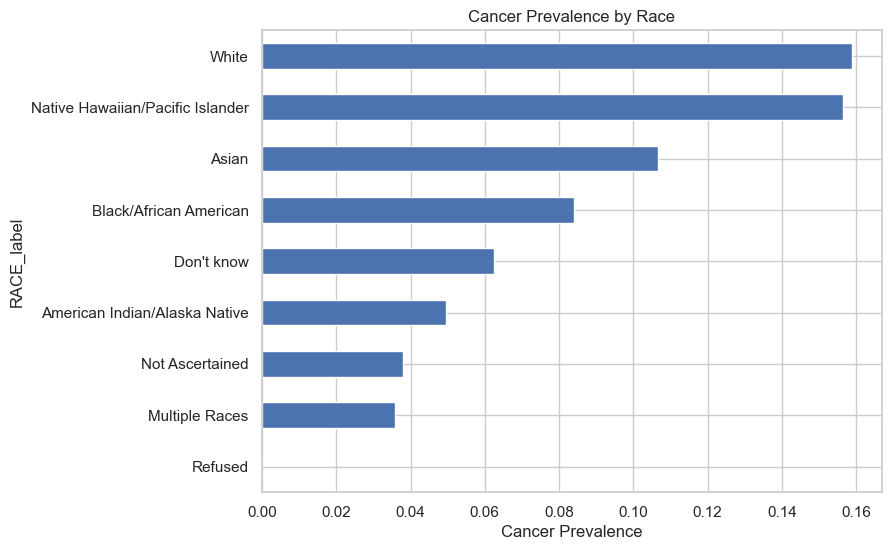

In [31]:
demo_rates = (
    clean_df
    .groupby("RACE_label")["Cancer"]
    .mean()
    .sort_values()
)

demo_rates.plot(kind="barh", figsize=(8,6))

plt.xlabel("Cancer Prevalence")
plt.title("Cancer Prevalence by Race")

plt.show()

In [32]:
vars_needed = [
    "SEX_A",
    "RACEALLP_A",
    "EDUCP_A",
    "CANEV_A",
    "WTFA_A"
]

analysis_df = df[vars_needed].copy()

In [33]:
clean_df = analysis_df[analysis_df["CANEV_A"].isin([1,2])].copy()

clean_df["Cancer"] = (clean_df["CANEV_A"] == 1).astype(int)

# Re-apply label mappings (needed for weighted analysis section)
clean_df["RACE_label"]  = clean_df["RACEALLP_A"].map(race_map)
clean_df["EDUC_label"]  = clean_df["EDUCP_A"].map(educ_map)
clean_df["SEX_label"]   = clean_df["SEX_A"].map(sex_map)
clean_df["CANEV_label"] = clean_df["CANEV_A"].map(cancer_map)

# Pull additional columns from full df (not included in analysis_df subset)
extra_cols = [
    'AGEP_A', 'EDUCP_A',
    'SLPHOURS_A', 'PA18_05R_A', 'BMICAT_A',
    'DRKHVY12M_A', 'DRKSTAT_A', 'SMKNOW_A',
    'DEPEV_A', 'ANXEV_A',
    'DIBEV_A', 'HYPEV_A', 'CHDEV_A', 'COPDEV_A', 'ARTHEV_A',
    'HICOV_A', 'USUALPL_A', 'FDSCAT4_A',
    'URBRRL23', 'REGION', 'POVRATTC_A', 'MARSTAT_A',
]
for col in extra_cols:
    if col not in clean_df.columns:
        clean_df[col] = df.loc[clean_df.index, col]


In [34]:
import numpy as np

def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

In [35]:
overall_prev = weighted_mean(clean_df["Cancer"], clean_df["WTFA_A"])

print("Weighted Cancer Prevalence:", overall_prev*100)

Weighted Cancer Prevalence: 10.274968304684881


In [36]:
weighted_race = (
    clean_df
    .groupby("RACE_label")
    .apply(lambda x: weighted_mean(x["Cancer"], x["WTFA_A"]))
)

weighted_race = weighted_race.sort_values(ascending=False)

weighted_race * 100

/var/folders/fn/2qb26h1s5m18wl47hxq_v9cm0000gn/T/ipykernel_83453/2764887773.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(x["Cancer"], x["WTFA_A"]))


RACE_label
White                               12.316710
Native Hawaiian/Pacific Islander    10.962477
Asian                                9.248783
Black/African American               6.410137
American Indian/Alaska Native        5.087611
Don't know                           4.619274
Not Ascertained                      2.910112
Multiple Races                       2.875474
Refused                              0.000000
dtype: float64

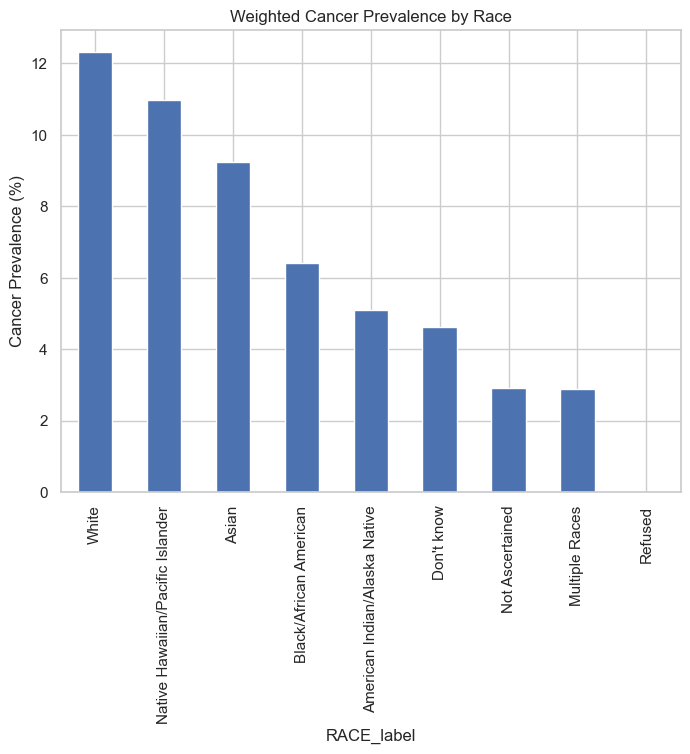

In [37]:
(weighted_race*100).plot(kind="bar", figsize=(8,6))

plt.ylabel("Cancer Prevalence (%)")
plt.title("Weighted Cancer Prevalence by Race")

plt.show()

In [38]:
weighted_heatmap = (
    clean_df
    .groupby(["RACE_label","EDUC_label"])
    .apply(lambda x: weighted_mean(x["Cancer"], x["WTFA_A"]))
    .unstack()
)

/var/folders/fn/2qb26h1s5m18wl47hxq_v9cm0000gn/T/ipykernel_83453/2924420696.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(x["Cancer"], x["WTFA_A"]))


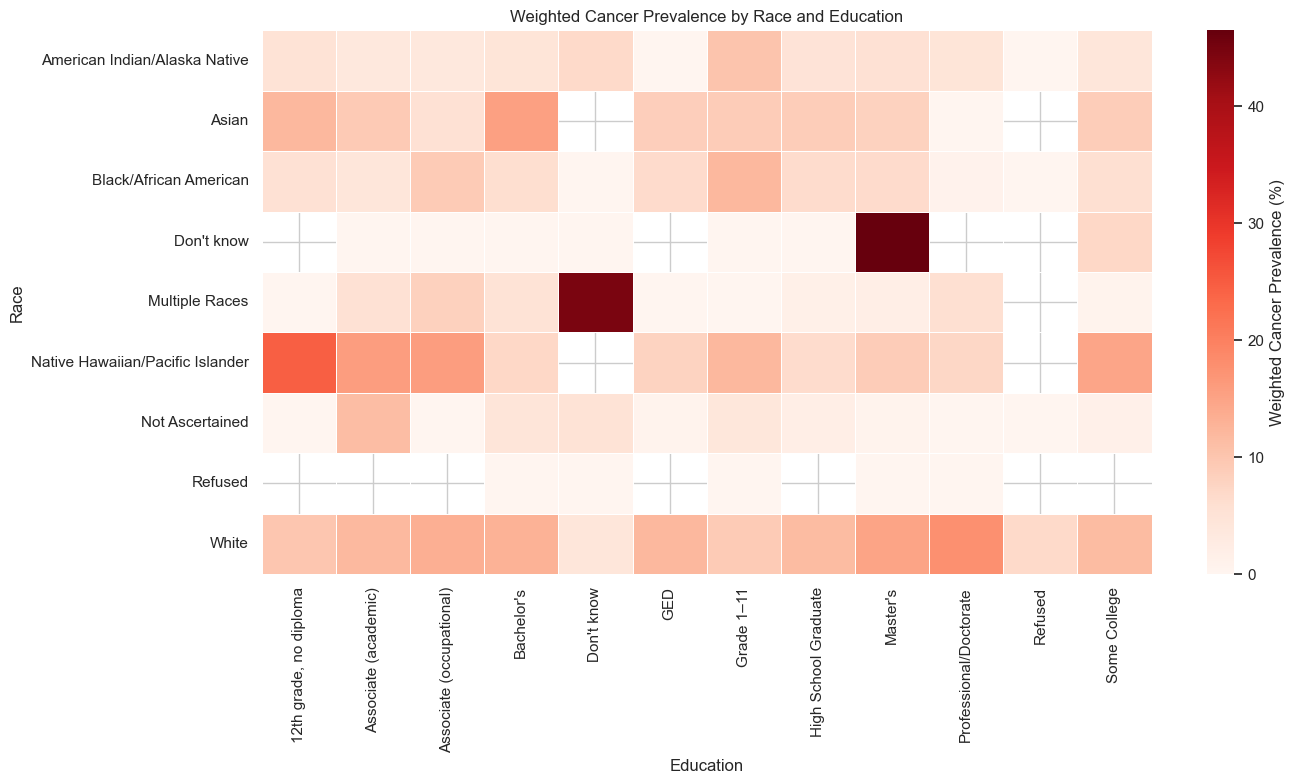

In [39]:
plt.figure(figsize=(14,8))

sns.heatmap(
    weighted_heatmap*100,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label":"Weighted Cancer Prevalence (%)"}
)

plt.title("Weighted Cancer Prevalence by Race and Education")
plt.xlabel("Education")
plt.ylabel("Race")

plt.tight_layout()

plt.show()

In [40]:
def weighted_se(x, w):
    p = weighted_mean(x, w)
    n_eff = (np.sum(w)**2) / np.sum(w**2)
    return np.sqrt(p*(1-p)/n_eff)

In [41]:
results = []

for race, group in clean_df.groupby("RACE_label"):
    
    p = weighted_mean(group["Cancer"], group["WTFA_A"])
    se = weighted_se(group["Cancer"], group["WTFA_A"])
    
    ci_low = p - 1.96*se
    ci_high = p + 1.96*se
    
    results.append({
        "Race": race,
        "Prevalence": p*100,
        "CI_low": ci_low*100,
        "CI_high": ci_high*100
    })

race_results = pd.DataFrame(results)

race_results

,Race,Prevalence,CI_low,CI_high
0,American Indian/Alaska Native,5.087611,3.904016,6.271207
1,Asian,9.248783,5.228055,13.269512
2,Black/African American,6.410137,5.376174,7.444100
3,Don't know,4.619274,-4.021725,13.260272
4,Multiple Races,2.875474,1.035417,4.715530
5,Native Hawaiian/Pacific Islander,10.962477,6.414488,15.510465
6,Not Ascertained,2.910112,1.955344,3.864879
7,Refused,0.000000,0.000000,0.000000
8,White,12.316710,11.810525,12.822895


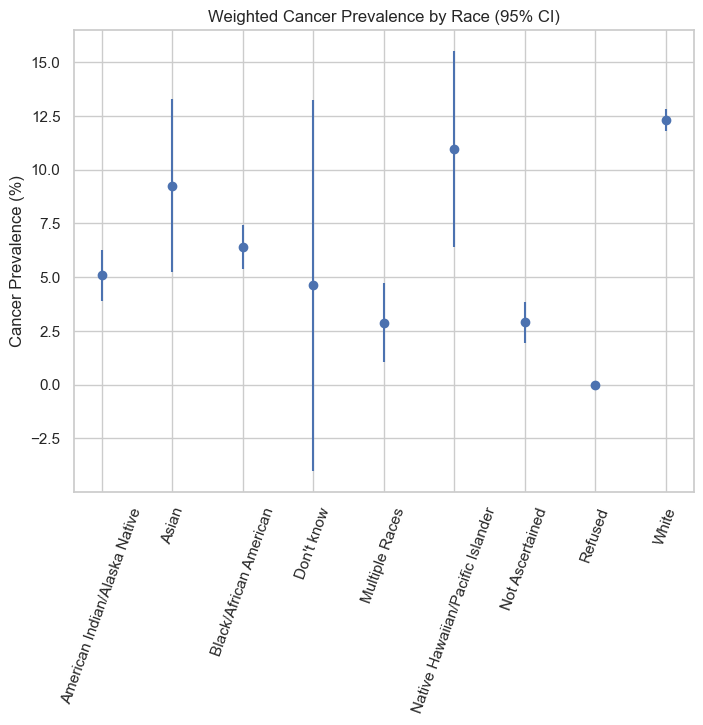

In [42]:
plt.figure(figsize=(8,6))

plt.errorbar(
    race_results["Race"],
    race_results["Prevalence"],
    yerr=[
        race_results["Prevalence"] - race_results["CI_low"],
        race_results["CI_high"] - race_results["Prevalence"]
    ],
    fmt='o'
)

plt.ylabel("Cancer Prevalence (%)")
plt.title("Weighted Cancer Prevalence by Race (95% CI)")

plt.xticks(rotation=70)
plt.show()

In [43]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [44]:
# Add age groups and grouped education to clean_df before modeling
age_bins  = [17, 29, 39, 49, 59, 69, 79, 120]
age_labels = ['18-29','30-39','40-49','50-59','60-69','70-79','80+']
clean_df['AGE_group'] = pd.cut(
    df.loc[clean_df.index, 'AGEP_A'].where(lambda x: x < 97),
    bins=age_bins, labels=age_labels
)

# Collapse education into 4 interpretable groups (drop refused/unknown)
educ_grp = {
    0: '< HS', 1: '< HS', 2: '< HS', 3: '< HS',
    4: 'HS/GED',
    5: 'Some College', 6: 'Some College', 7: 'Some College',
    8: "Bachelor's+", 9: "Bachelor's+", 10: "Bachelor's+",
}
clean_df['EDUC_grp'] = clean_df['EDUCP_A'].map(educ_grp)

# Keep only valid race categories (drop refused/unknown/not ascertained)
valid_race = ['White','Black/African American','American Indian/Alaska Native',
              'Asian','Native Hawaiian/Pacific Islander','Multiple Races']

model_df = clean_df[
    clean_df['RACE_label'].isin(valid_race) &
    clean_df['SEX_label'].isin(['Male','Female']) &
    clean_df['EDUC_grp'].notna() &
    clean_df['AGE_group'].notna()
].copy()

print(f"Model dataset: {len(model_df):,} respondents")
print(f"Cancer cases:  {model_df['Cancer'].sum():,} ({model_df['Cancer'].mean()*100:.1f}%)")

# Fit weighted logistic regression
# var_weights scales the variance (correct for probability/survey weights)
# Reference categories: White, Male, HS/GED, 18-29
model = smf.glm(
    formula="""Cancer ~ C(AGE_group,  Treatment('18-29'))
                      + C(SEX_label,  Treatment('Male'))
                      + C(RACE_label, Treatment('White'))
                      + C(EDUC_grp,   Treatment('HS/GED'))""",
    data=model_df,
    family=sm.families.Binomial(),
    var_weights=model_df['WTFA_A']
)

results = model.fit()
print(results.summary())


Model dataset: 30,723 respondents
Cancer cases:  4,351 (14.2%)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Cancer   No. Observations:                30723
Model:                            GLM   Df Residuals:                    30707
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.7745e+07
Date:                Fri, 03 Apr 2026   Deviance:                   1.3549e+08
Time:                        15:11:00   Pearson chi2:                 2.40e+08
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [45]:
params = results.params
ci     = results.conf_int()
pvals  = results.pvalues

or_table = pd.DataFrame({
    'Odds Ratio': np.exp(params),
    'CI Low':     np.exp(ci[0]),
    'CI High':    np.exp(ci[1]),
    'p-value':    pvals
}).drop('Intercept')

or_table['Significant'] = or_table['p-value'] < 0.05
print(or_table.round(3).to_string())


                                                                       Odds Ratio  CI Low  CI High  p-value  Significant
C(AGE_group, Treatment('18-29'))[T.30-39]                                   2.005   1.998    2.012      0.0         True
C(AGE_group, Treatment('18-29'))[T.40-49]                                   4.766   4.750    4.781      0.0         True
C(AGE_group, Treatment('18-29'))[T.50-59]                                  10.333  10.301   10.365      0.0         True
C(AGE_group, Treatment('18-29'))[T.60-69]                                  20.620  20.558   20.682      0.0         True
C(AGE_group, Treatment('18-29'))[T.70-79]                                  35.440  35.334   35.546      0.0         True
C(AGE_group, Treatment('18-29'))[T.80+]                                    54.260  54.093   54.428      0.0         True
C(SEX_label, Treatment('Male'))[T.Female]                                   1.058   1.057    1.059      0.0         True
C(RACE_label, Treatment('White')

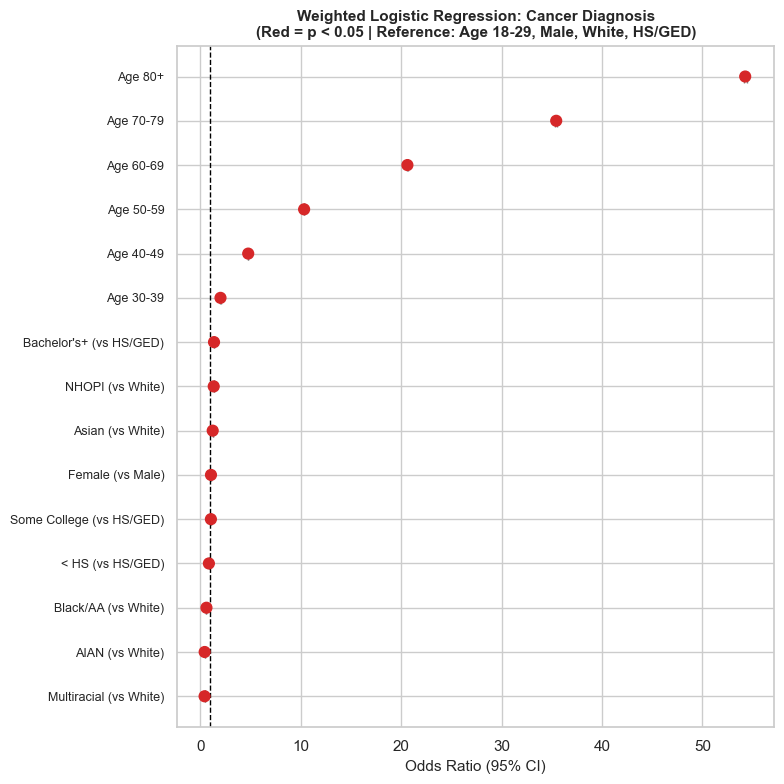

In [46]:
# Clean up coefficient names for display
label_map = {
    "C(AGE_group, Treatment('18-29'))[T.30-39]":   "Age 30-39",
    "C(AGE_group, Treatment('18-29'))[T.40-49]":   "Age 40-49",
    "C(AGE_group, Treatment('18-29'))[T.50-59]":   "Age 50-59",
    "C(AGE_group, Treatment('18-29'))[T.60-69]":   "Age 60-69",
    "C(AGE_group, Treatment('18-29'))[T.70-79]":   "Age 70-79",
    "C(AGE_group, Treatment('18-29'))[T.80+]":     "Age 80+",
    "C(SEX_label, Treatment('Male'))[T.Female]":   "Female (vs Male)",
    "C(RACE_label, Treatment('White'))[T.American Indian/Alaska Native]": "AIAN (vs White)",
    "C(RACE_label, Treatment('White'))[T.Asian]":  "Asian (vs White)",
    "C(RACE_label, Treatment('White'))[T.Black/African American]": "Black/AA (vs White)",
    "C(RACE_label, Treatment('White'))[T.Multiple Races]": "Multiracial (vs White)",
    "C(RACE_label, Treatment('White'))[T.Native Hawaiian/Pacific Islander]": "NHOPI (vs White)",
    "C(EDUC_grp, Treatment('HS/GED'))[T.< HS]":       "< HS (vs HS/GED)",
    "C(EDUC_grp, Treatment('HS/GED'))[T.Bachelor's+]": "Bachelor's+ (vs HS/GED)",
    "C(EDUC_grp, Treatment('HS/GED'))[T.Some College]":"Some College (vs HS/GED)",
}

plot_df = or_table.copy()
plot_df.index = plot_df.index.map(lambda x: label_map.get(x, x))
plot_df = plot_df.sort_values('Odds Ratio')

fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#d62728' if s else '#6baed6' for s in plot_df['Significant']]
y_pos  = range(len(plot_df))

ax.scatter(plot_df['Odds Ratio'], y_pos, color=colors, zorder=5, s=60)
ax.errorbar(
    plot_df['Odds Ratio'], y_pos,
    xerr=[plot_df['Odds Ratio'] - plot_df['CI Low'],
          plot_df['CI High']    - plot_df['Odds Ratio']],
    fmt='none', color='gray', capsize=4, linewidth=1.2
)

ax.axvline(1, linestyle='--', color='black', linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=11)
ax.set_title(
    'Weighted Logistic Regression: Cancer Diagnosis\n'
    '(Red = p < 0.05 | Reference: Age 18-29, Male, White, HS/GED)',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.show()


In [47]:
# Significant predictors summary
sig = or_table[or_table['Significant']].sort_values('Odds Ratio', ascending=False)
print("Significant predictors (p < 0.05):")
print(sig[['Odds Ratio','CI Low','CI High','p-value']].round(3).to_string())


Significant predictors (p < 0.05):
                                                                       Odds Ratio  CI Low  CI High  p-value
C(AGE_group, Treatment('18-29'))[T.80+]                                    54.260  54.093   54.428      0.0
C(AGE_group, Treatment('18-29'))[T.70-79]                                  35.440  35.334   35.546      0.0
C(AGE_group, Treatment('18-29'))[T.60-69]                                  20.620  20.558   20.682      0.0
C(AGE_group, Treatment('18-29'))[T.50-59]                                  10.333  10.301   10.365      0.0
C(AGE_group, Treatment('18-29'))[T.40-49]                                   4.766   4.750    4.781      0.0
C(AGE_group, Treatment('18-29'))[T.30-39]                                   2.005   1.998    2.012      0.0
C(EDUC_grp, Treatment('HS/GED'))[T.Bachelor's+]                             1.361   1.360    1.363      0.0
C(RACE_label, Treatment('White'))[T.Native Hawaiian/Pacific Islander]       1.330   1.324    1.337   

In [49]:
df["AGEP_A"].describe()

count    32629.000000
mean        53.453278
std         18.673458
min         18.000000
25%         37.000000
50%         55.000000
75%         69.000000
max         99.000000
Name: AGEP_A, dtype: float64

---
## Extended Analysis: Poster Visualizations

### #8 — Cancer Prevalence by Age & Sex

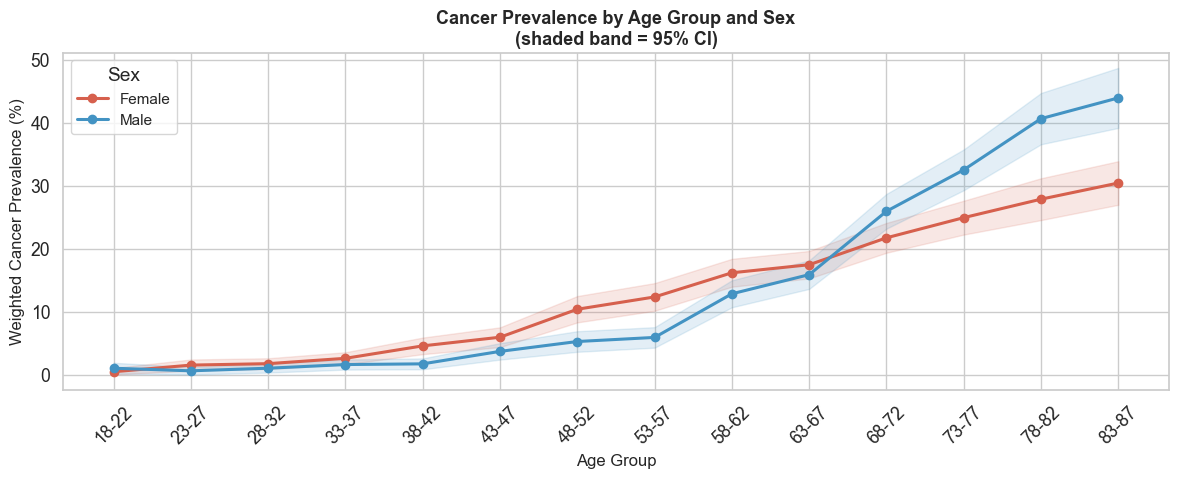

Sex    Female   Male
Age                 
18-22    0.44   1.00
23-27    1.50   0.59
28-32    1.73   1.00
33-37    2.58   1.59
38-42    4.55   1.70
43-47    5.92   3.68
48-52   10.37   5.24
53-57   12.32   5.89
58-62   16.15  12.82
63-67   17.43  15.86
68-72   21.70  25.92
73-77   24.90  32.50
78-82   27.84  40.62
83-87   30.40  43.91


In [50]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns, statsmodels.api as sm, statsmodels.formula.api as smf, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.15)

def wt_prev(x, w):
    m = pd.notna(x) & pd.notna(w)
    return np.sum(w[m]*x[m]) / np.sum(w[m])

def wt_se(x, w):
    p = wt_prev(x, w)
    m = pd.notna(x) & pd.notna(w)
    n_eff = np.sum(w[m])**2 / np.sum(w[m]**2)
    return np.sqrt(p*(1-p)/n_eff)

# Use single-year age, cap at 84 (85 = 85+)
age_sex = clean_df[clean_df['AGEP_A'] < 97].copy()
age_sex['age_grp'] = pd.cut(age_sex['AGEP_A'], bins=list(range(18,86,5))+[120],
                             labels=[f'{a}-{a+4}' for a in range(18,85,5)], right=False)

rows = []
for sex in ['Male','Female']:
    for ag, sub in age_sex[age_sex['SEX_label']==sex].groupby('age_grp', observed=True):
        if len(sub) < 20: continue
        p  = wt_prev(sub['Cancer'], sub['WTFA_A'])
        se = wt_se(sub['Cancer'],  sub['WTFA_A'])
        rows.append({'Sex':sex,'Age':str(ag),'Prev':p*100,
                     'Lo':max(0,p-1.96*se)*100,'Hi':(p+1.96*se)*100})

as_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12,5))
palette = {'Male':'#4393c3','Female':'#d6604d'}
for sex, grp in as_df.groupby('Sex'):
    ax.plot(grp['Age'], grp['Prev'], marker='o', label=sex,
            color=palette[sex], linewidth=2.2)
    ax.fill_between(grp['Age'], grp['Lo'], grp['Hi'],
                    alpha=0.15, color=palette[sex])

ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Weighted Cancer Prevalence (%)', fontsize=12)
ax.set_title('Cancer Prevalence by Age Group and Sex\n(shaded band = 95% CI)',
             fontsize=13, fontweight='bold')
ax.legend(title='Sex', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(as_df.pivot(index='Age', columns='Sex', values='Prev').round(2).to_string())


### #1 — Age-of-Diagnosis Distributions by Cancer Type

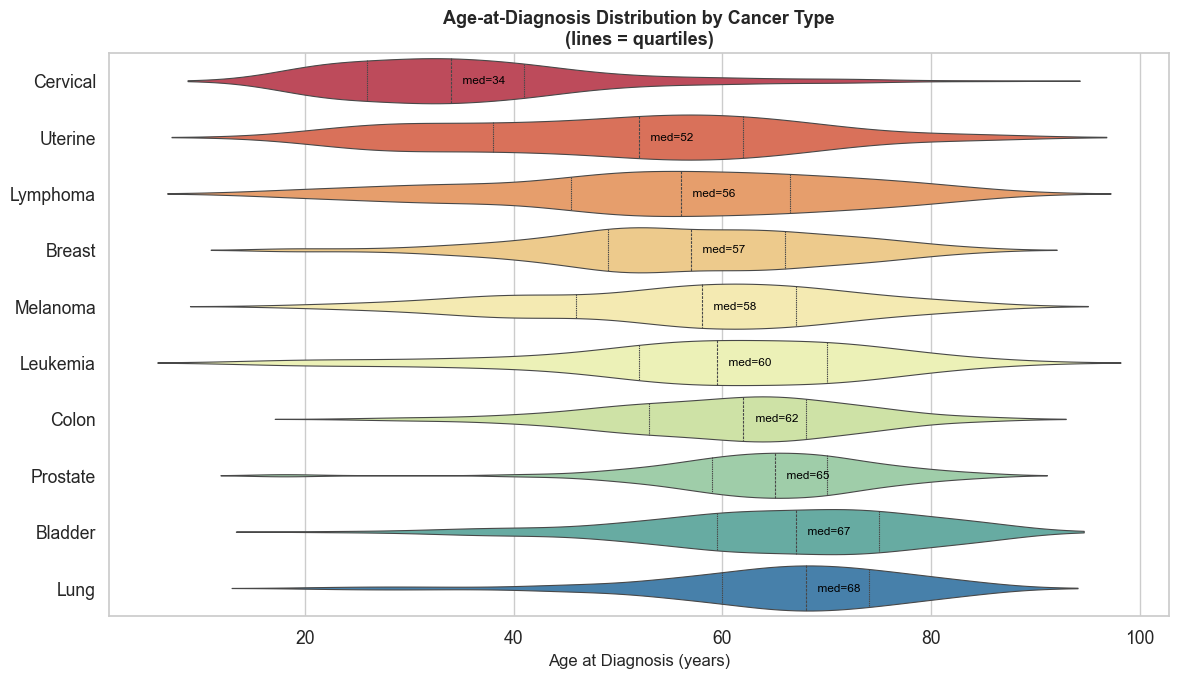


Median age at diagnosis:
Cancer
Cervical    34.0
Uterine     52.0
Lymphoma    56.0
Breast      57.0
Melanoma    58.0
Leukemia    59.5
Colon       62.0
Prostate    65.0
Bladder     67.0
Lung        68.0


In [51]:

cancer_agetc = {
    'Breast':    'BREASAGETC_A',
    'Prostate':  'PROSTAGETC_A',
    'Colon':     'COLONAGETC_A',
    'Melanoma':  'MELANAGETC_A',
    'Lung':      'LUNGAGETC_A',
    'Cervical':  'CERVIAGETC_A',
    'Uterine':   'UTERUAGETC_A',
    'Bladder':   'BLADDAGETC_A',
    'Lymphoma':  'LYMPHAGETC_A',
    'Leukemia':  'LEUKEAGETC_A',
}

aod_rows = []
for name, col in cancer_agetc.items():
    ages = df[col].dropna()
    ages = ages[(ages >= 18) & (ages < 86)]   # adults, cap 85=85+
    for a in ages:
        aod_rows.append({'Cancer': name, 'Age at Diagnosis': a})

aod_df = pd.DataFrame(aod_rows)
medians = aod_df.groupby('Cancer')['Age at Diagnosis'].median().sort_values()
order   = medians.index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))
palette_aod = sns.color_palette('Spectral', len(order))
sns.violinplot(data=aod_df, y='Cancer', x='Age at Diagnosis',
               order=order, palette=palette_aod,
               inner='quartile', linewidth=0.8, ax=ax)
ax.set_xlabel('Age at Diagnosis (years)', fontsize=12)
ax.set_ylabel('')
ax.set_title('Age-at-Diagnosis Distribution by Cancer Type\n(lines = quartiles)',
             fontsize=13, fontweight='bold')

# Annotate median
for i, cancer in enumerate(order):
    med = medians[cancer]
    ax.text(med+0.5, i, f'  med={med:.0f}', va='center', fontsize=8.5, color='black')

plt.tight_layout()
plt.show()

print("\nMedian age at diagnosis:")
print(medians.round(1).to_string())


### #2 — Cancer Survivor Profile Dashboard

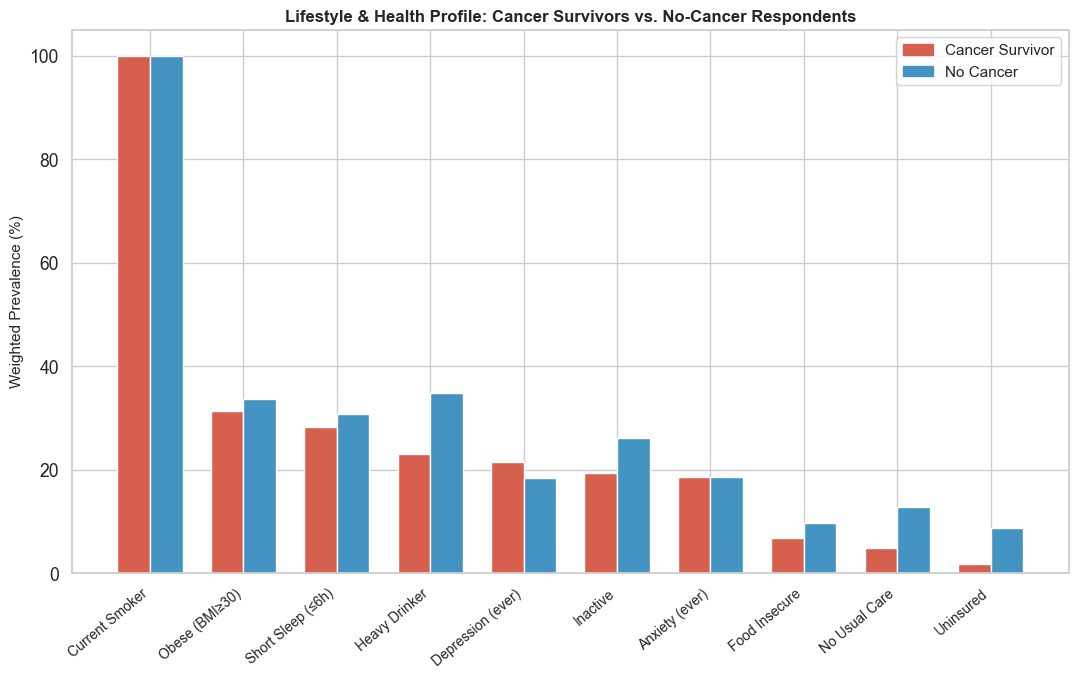

In [52]:

# Build survivor vs non-survivor comparison dataset
surv_vars = {
    'Current Smoker':        ('SMKNOW_A',    lambda x: x.isin([1,2]),   lambda x: x.isin([1,2])),
    'Heavy Drinker':         ('DRKHVY12M_A', lambda x: x.isin([1,2]),   lambda x: x == 1),
    'Obese (BMI≥30)':        ('BMICAT_A',    lambda x: x.isin([1,2,3,4]),lambda x: x == 4),
    'Inactive':              ('PA18_05R_A',  lambda x: x.isin([1,2,3,4]),lambda x: x == 4),
    'Short Sleep (≤6h)':     ('SLPHOURS_A',  lambda x: (x>=1)&(x<=20),  lambda x: x <= 6),
    'Depression (ever)':     ('DEPEV_A',     lambda x: x.isin([1,2]),   lambda x: x == 1),
    'Anxiety (ever)':        ('ANXEV_A',     lambda x: x.isin([1,2]),   lambda x: x == 1),
    'Uninsured':             ('HICOV_A',     lambda x: x.isin([1,2]),   lambda x: x == 2),
    'No Usual Care':         ('USUALPL_A',   lambda x: x.isin([1,2,3]), lambda x: x.isin([2,3])),
    'Food Insecure':         ('FDSCAT4_A',   lambda x: x.isin([1,2,3,4]),lambda x: x.isin([3,4])),
}

profile_rows = []
for label, (col, valid_fn, positive_fn) in surv_vars.items():
    for group, flag in [('Survivor', 1), ('No Cancer', 0)]:
        sub = clean_df[clean_df['Cancer'] == flag].copy()
        sub = sub[valid_fn(sub[col])]
        if len(sub) == 0: continue
        pct = wt_prev(positive_fn(sub[col]).astype(int), sub['WTFA_A']) * 100
        profile_rows.append({'Factor': label, 'Group': group, 'Pct': pct})

prof_df = pd.DataFrame(profile_rows)

# Sort by survivor prevalence
surv_order = (prof_df[prof_df['Group']=='Survivor']
              .set_index('Factor')['Pct'].sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(11, 7))
x   = np.arange(len(surv_order))
w   = 0.35
col_s = '#d6604d'
col_n = '#4393c3'

for i, factor in enumerate(surv_order):
    sv = prof_df[(prof_df['Factor']==factor)&(prof_df['Group']=='Survivor')]['Pct'].values
    nc = prof_df[(prof_df['Factor']==factor)&(prof_df['Group']=='No Cancer')]['Pct'].values
    if sv.size: ax.bar(i-w/2, sv[0], w, color=col_s, edgecolor='white')
    if nc.size: ax.bar(i+w/2, nc[0], w, color=col_n, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(surv_order, rotation=40, ha='right', fontsize=10)
ax.set_ylabel('Weighted Prevalence (%)', fontsize=11)
ax.set_title('Lifestyle & Health Profile: Cancer Survivors vs. No-Cancer Respondents',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=col_s, label='Cancer Survivor'),
                   Patch(color=col_n, label='No Cancer')],
          fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


### #3 — Multimorbidity Burden Among Cancer Survivors

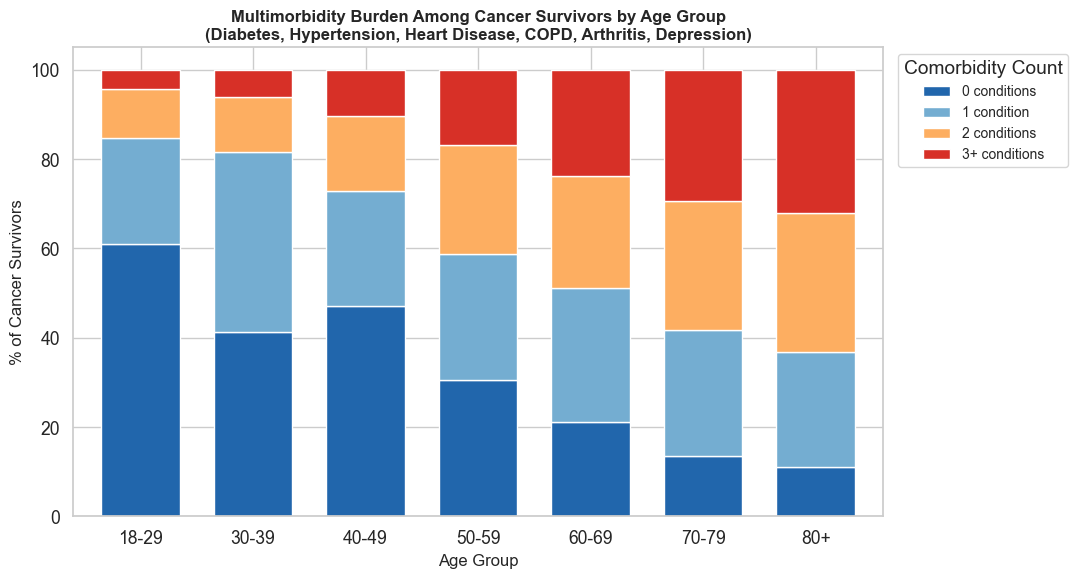


Raw counts by age and comorbidity burden:
comorb_cat  0 conditions  1 condition  2 conditions  3+ conditions
AGE_group2                                                        
18-29                 28           11             5              2
30-39                 47           46            14              7
40-49                109           60            39             24
50-59                150          138           120             83
60-69                244          346           289            273
70-79                195          411           419            428
80+                  103          241           292            301


In [53]:

survivors = clean_df[clean_df['Cancer'] == 1].copy()

# Flag each comorbidity (1=Yes, 2=No)
survivors['has_diab']  = (survivors['DIBEV_A']  == 1).astype(int)
survivors['has_hyp']   = (survivors['HYPEV_A']  == 1).astype(int)
survivors['has_chd']   = (survivors['CHDEV_A']  == 1).astype(int)
survivors['has_copd']  = (survivors['COPDEV_A'] == 1).astype(int)
survivors['has_arth']  = (survivors['ARTHEV_A'] == 1).astype(int)
survivors['has_dep']   = (survivors['DEPEV_A']  == 1).astype(int)

comorb_cols = ['has_diab','has_hyp','has_chd','has_copd','has_arth','has_dep']
survivors['n_comorb'] = survivors[comorb_cols].sum(axis=1)

# Collapse 3+ into one bucket
survivors['comorb_cat'] = survivors['n_comorb'].clip(upper=3).map(
    {0:'0 conditions', 1:'1 condition', 2:'2 conditions', 3:'3+ conditions'})

age_order_m = ['18-29','30-39','40-49','50-59','60-69','70-79','80+']
survivors['AGE_group2'] = pd.cut(
    df.loc[survivors.index, 'AGEP_A'].where(lambda x: x < 97),
    bins=[17,29,39,49,59,69,79,120], labels=age_order_m)

ct = (survivors.dropna(subset=['AGE_group2'])
      .groupby(['AGE_group2','comorb_cat'], observed=True)
      .size().unstack(fill_value=0))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

comorb_order = ['0 conditions','1 condition','2 conditions','3+ conditions']
ct_pct = ct_pct[[c for c in comorb_order if c in ct_pct.columns]]

fig, ax = plt.subplots(figsize=(11,6))
palette_m = ['#2166ac','#74add1','#fdae61','#d73027']
ct_pct.plot(kind='bar', stacked=True, ax=ax, color=palette_m, edgecolor='white', width=0.7)

ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('% of Cancer Survivors', fontsize=12)
ax.set_title('Multimorbidity Burden Among Cancer Survivors by Age Group\n(Diabetes, Hypertension, Heart Disease, COPD, Arthritis, Depression)',
             fontsize=12, fontweight='bold')
ax.legend(title='Comorbidity Count', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nRaw counts by age and comorbidity burden:")
print(ct.to_string())


### #5 — Physical Activity × BMI Interaction

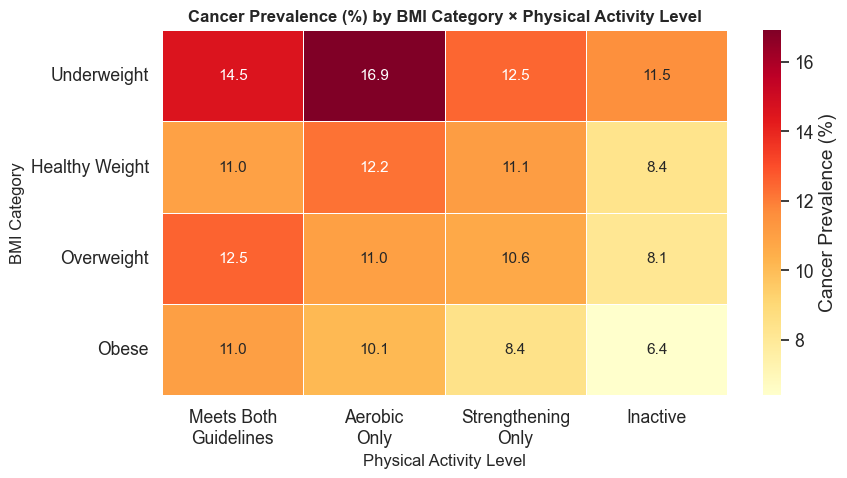

PA_short        Meets Both\nGuidelines  Aerobic\nOnly  Strengthening\nOnly  Inactive
BMI_short                                                                           
Underweight                      14.54          16.92                12.47     11.54
Healthy Weight                   10.95          12.20                11.09      8.36
Overweight                       12.55          10.97                10.65      8.12
Obese                            11.03          10.13                 8.43      6.40


In [54]:

pa_bmi = clean_df[
    clean_df['PA18_05R_A'].isin([1,2,3,4]) &
    clean_df['BMICAT_A'].isin([1,2,3,4])
].copy()

pa_label_map = {1:'Meets Both\nGuidelines', 2:'Aerobic\nOnly',
                3:'Strengthening\nOnly',     4:'Inactive'}
bmi_label_map= {1:'Underweight', 2:'Healthy Weight', 3:'Overweight', 4:'Obese'}

pa_bmi['PA_short']  = pa_bmi['PA18_05R_A'].map(pa_label_map)
pa_bmi['BMI_short'] = pa_bmi['BMICAT_A'].map(bmi_label_map)

hm = (pa_bmi.groupby(['BMI_short','PA_short'], observed=True)
      .apply(lambda x: wt_prev(x['Cancer'], x['WTFA_A']))
      .unstack() * 100)

bmi_ord = ['Underweight','Healthy Weight','Overweight','Obese']
pa_ord  = ['Meets Both\nGuidelines','Aerobic\nOnly','Strengthening\nOnly','Inactive']
hm = hm.reindex(index=[b for b in bmi_ord if b in hm.index],
                columns=[p for p in pa_ord if p in hm.columns])

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(hm, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.6,
            cbar_kws={'label':'Cancer Prevalence (%)'}, ax=ax, annot_kws={'size':11})
ax.set_xlabel('Physical Activity Level', fontsize=12)
ax.set_ylabel('BMI Category', fontsize=12)
ax.set_title('Cancer Prevalence (%) by BMI Category × Physical Activity Level',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(hm.round(2).to_string())


### #4 — Social Determinants Radar Chart

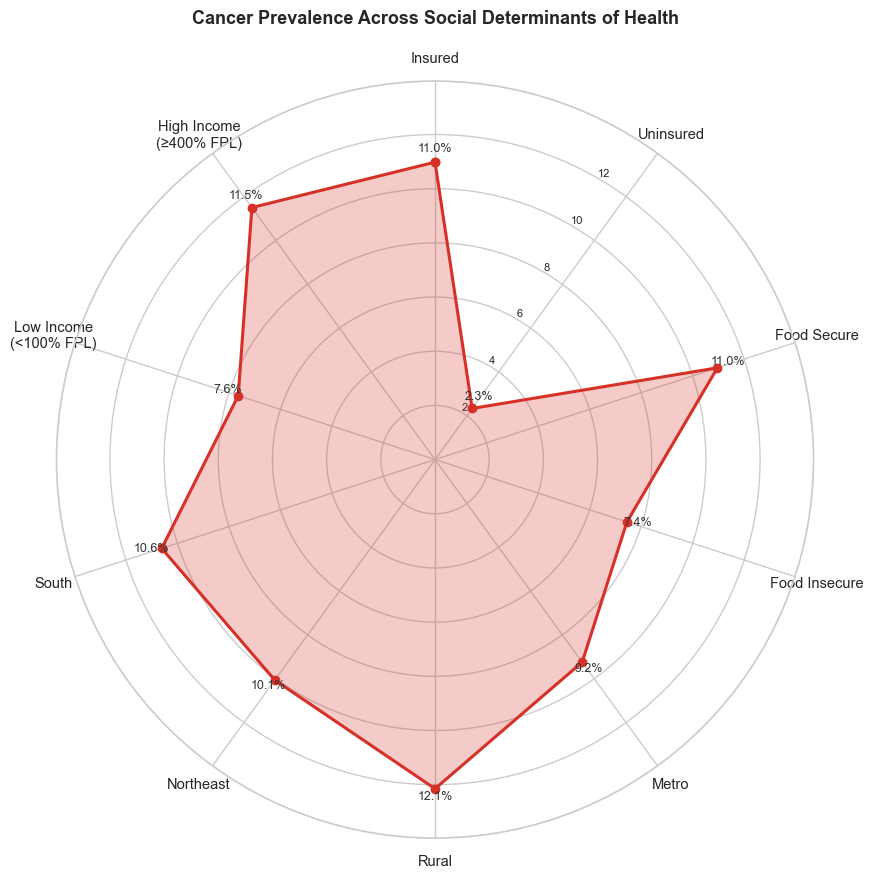


Cancer prevalence by SDOH group:
  Insured                       : 10.98%
  Uninsured                     : 2.33%
  Food Secure                   : 10.96%
  Food Insecure                 : 7.45%
  Metro                         : 9.24%
  Rural                         : 12.15%
  Northeast                     : 10.06%
  South                         : 10.61%
  Low Income (<100% FPL)        : 7.64%
  High Income (≥400% FPL)       : 11.50%


In [55]:

import matplotlib.patches as mpatches

# Compute weighted cancer prevalence for each SDOH factor level
sdoh_groups = {
    'Insured':         clean_df[clean_df['HICOV_A']==1],
    'Uninsured':       clean_df[clean_df['HICOV_A']==2],
    'Food Secure':     clean_df[clean_df['FDSCAT4_A']==1],
    'Food Insecure':   clean_df[clean_df['FDSCAT4_A'].isin([3,4])],
    'Metro':           clean_df[clean_df['URBRRL23'].isin([1,2])],
    'Rural':           clean_df[clean_df['URBRRL23']==4],
    'Northeast':       clean_df[clean_df['REGION']==1],
    'South':           clean_df[clean_df['REGION']==3],
    'Low Income\n(<100% FPL)':  clean_df[clean_df['POVRATTC_A'].between(0,1.0)],
    'High Income\n(≥400% FPL)': clean_df[clean_df['POVRATTC_A']>=4.0],
}

sdoh_prev = {}
for label, sub in sdoh_groups.items():
    sdoh_prev[label] = wt_prev(sub['Cancer'], sub['WTFA_A']) * 100

labels  = list(sdoh_prev.keys())
values  = list(sdoh_prev.values())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values_plot = values + values[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.plot(angles, values_plot, 'o-', linewidth=2.2, color='#d73027')
ax.fill(angles, values_plot, alpha=0.25, color='#d73027')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10.5)

max_val = max(values) * 1.15
ax.set_ylim(0, max_val)
ax.yaxis.set_tick_params(labelsize=8)
ax.set_rlabel_position(30)

for angle, val, label in zip(angles[:-1], values, labels):
    ax.annotate(f'{val:.1f}%',
                xy=(angle, val), xytext=(angle, val+0.4),
                fontsize=9, ha='center', color='#333333')

ax.set_title('Cancer Prevalence Across Social Determinants of Health',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCancer prevalence by SDOH group:")
for k,v in sdoh_prev.items():
    print(f"  {k.replace(chr(10),' '):30s}: {v:.2f}%")


### #10 — Geographic Heatmap: Region × Urbanicity

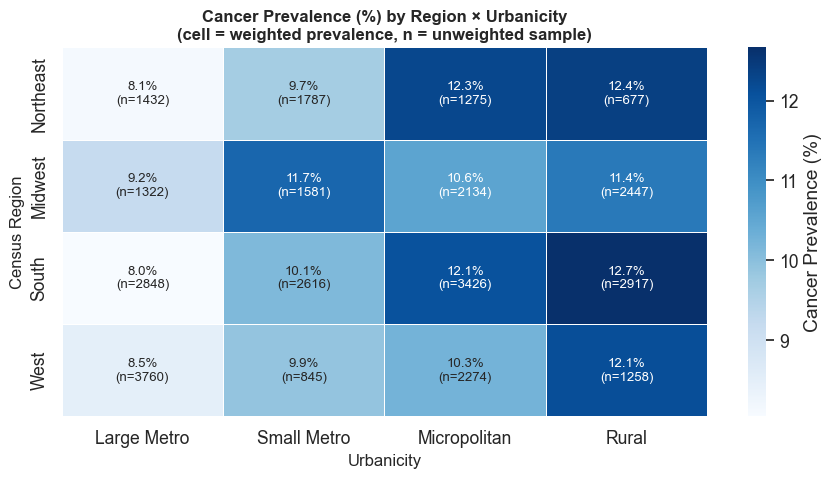

Urbanicity  Large Metro  Small Metro  Micropolitan  Rural
Region                                                   
Northeast          8.12         9.68         12.26  12.40
Midwest            9.21        11.71         10.57  11.38
South              8.05        10.13         12.06  12.67
West               8.49         9.90         10.27  12.14


In [56]:

region_map_geo = {1:'Northeast', 2:'Midwest', 3:'South', 4:'West'}
urban_map_geo  = {1:'Large Metro', 2:'Small Metro', 3:'Micropolitan', 4:'Rural'}

geo = clean_df.copy()
geo['Region'] = geo['REGION'].map(region_map_geo)
geo['Urbanicity'] = geo['URBRRL23'].map(urban_map_geo)

geo_hm = (geo.groupby(['Region','Urbanicity'], observed=True)
          .apply(lambda x: wt_prev(x['Cancer'], x['WTFA_A']))
          .unstack() * 100)

region_ord = ['Northeast','Midwest','South','West']
urban_ord  = ['Large Metro','Small Metro','Micropolitan','Rural']
geo_hm = geo_hm.reindex(
    index=[r for r in region_ord if r in geo_hm.index],
    columns=[u for u in urban_ord if u in geo_hm.columns])

# Also compute sample sizes for annotation
geo_n = (geo.groupby(['Region','Urbanicity'], observed=True)
         .size().unstack(fill_value=0))
geo_n = geo_n.reindex(
    index=[r for r in region_ord if r in geo_n.index],
    columns=[u for u in urban_ord if u in geo_n.columns])

annot = geo_hm.round(1).astype(str) + '%\n(n=' + geo_n.astype(str) + ')'

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(geo_hm, annot=annot, fmt='', cmap='Blues', linewidths=0.6,
            cbar_kws={'label':'Cancer Prevalence (%)'}, ax=ax,
            annot_kws={'size':9.5})
ax.set_xlabel('Urbanicity', fontsize=12)
ax.set_ylabel('Census Region', fontsize=12)
ax.set_title('Cancer Prevalence (%) by Region × Urbanicity\n(cell = weighted prevalence, n = unweighted sample)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(geo_hm.round(2).to_string())
